In [137]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS


In [138]:
apple_panel = pd.read_csv('apple_panel_with_frost.csv')
apple_panel = apple_panel[(apple_panel['year'] >= 2010) & (apple_panel['year'] <= 2020)].copy()

print(apple_panel.head(10))

              county  year   log_prod  log_price  log_wa_price  frost_days  \
0              Brant  2020   8.578288   3.465736      3.756394       127.0   
1       Chatham-Kent  2020   8.732305   3.443618      3.756394       101.2   
2              Elgin  2020  10.400741   3.481240      3.756394       104.4   
3              Essex  2020  10.181612   3.449988      3.756394        79.8   
4  Haldimand-Norfolk  2020  10.913487   3.397858      3.756394       102.0   
5           Hamilton  2020   9.019422   3.367296      3.756394       115.8   
6            Lambton  2020   9.585278   3.401197      3.756394       104.4   
7          Middlesex  2020   9.589598   3.446808      3.756394       125.2   
8            Niagara  2020   9.732106   3.459466      3.756394        76.0   
9             Oxford  2020   7.087574   3.496508      3.756394       129.4   

   log_frost  
0   4.844187  
1   4.617099  
2   4.648230  
3   4.379524  
4   4.624973  
5   4.751865  
6   4.648230  
7   4.829912  
8   4.

In [139]:
vars_of_interest = {
    'log_prod': 'Log Marketed Production (000 lbs)',
    'log_price': 'Log Farm-Gate Price (¢/lb)',
    'log_wa_price': 'Log Washington State Price (¢/lb)',
    'frost_days': 'Annual Frost Days (days/year)',
}

rows = []
for var, label in vars_of_interest.items():
    col = apple_panel[var]
    rows.append({
        'Variable': label,
        'Mean': col.mean(),
        'Std. Dev.': col.std(),
        'Min': col.min(),
        'Max': col.max(),
        'N': col.count()
    })

summary = pd.DataFrame(rows).set_index('Variable')
summary = summary.round(3)
print(summary.to_string())

                                      Mean  Std. Dev.     Min      Max    N
Variable                                                                   
Log Marketed Production (000 lbs)    7.739      1.668   3.714   11.325  407
Log Farm-Gate Price (¢/lb)           3.467      0.254   3.063    3.912  407
Log Washington State Price (¢/lb)    3.658      0.167   3.355    3.920  407
Annual Frost Days (days/year)      132.288     19.745  70.400  188.000  407


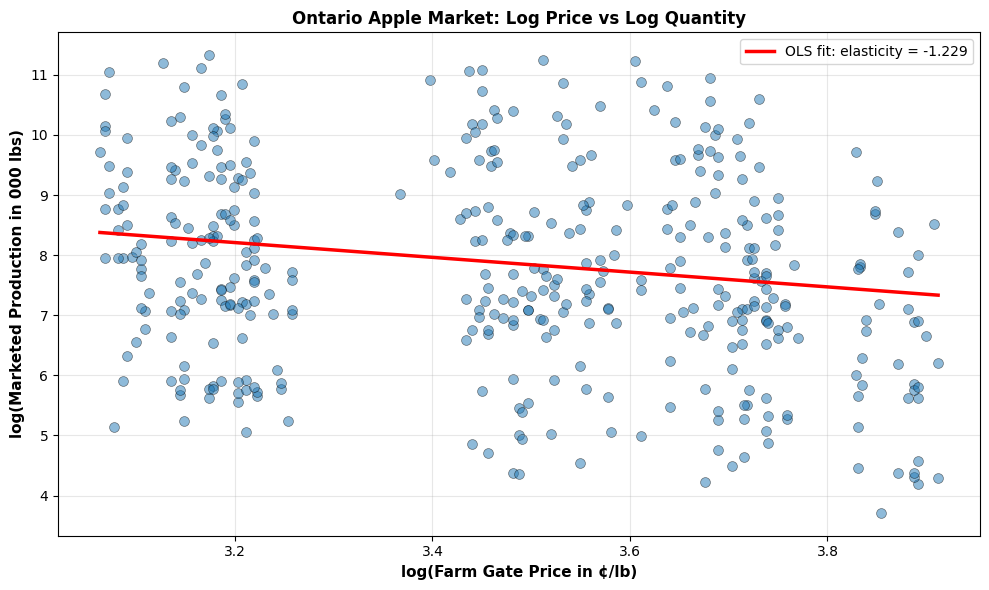

In [140]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(apple_panel['log_price'], apple_panel['log_prod'], alpha=0.5, s=50, edgecolors='black', linewidth=0.5)

x_range = np.linspace(apple_panel['log_price'].min(), apple_panel['log_price'].max(), 100)
y_fitted = 12.1405 + (-1.2286) * x_range
plt.plot(x_range, y_fitted, color='red', linewidth=2.5, label=f'OLS fit: elasticity = -1.229')

plt.xlabel('log(Farm Gate Price in ¢/lb)', fontsize=11, fontweight='bold')
plt.ylabel('log(Marketed Production in 000 lbs)', fontsize=11, fontweight='bold')
plt.title('Ontario Apple Market: Log Price vs Log Quantity', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Specification 1

Naive OLS. 

In [141]:
X1 = sm.add_constant(apple_panel[['log_price']])
y = apple_panel['log_prod']
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               log_prod   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     22.19
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           3.40e-06
Time:                        13:43:19   Log-Likelihood:                -774.47
No. Observations:                 407   AIC:                             1553.
Df Residuals:                     405   BIC:                             1561.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.9278      1.104     11.705      0.0

# Specification 2

Add County FE. 

In [142]:
county_dummies = pd.get_dummies(apple_panel['county'], drop_first=True).astype(int)
X2 = sm.add_constant(pd.concat([apple_panel[['log_price']], county_dummies], axis=1))
model2 = sm.OLS(y, X2).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:               log_prod   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     144.8
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          3.57e-197
Time:                        13:43:19   Log-Likelihood:                -221.77
No. Observations:                 407   AIC:                             521.5
Df Residuals:                     368   BIC:                             677.9
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Within R-squared

In [143]:
y_resid = sm.OLS(apple_panel['log_prod'], 
                 sm.add_constant(county_dummies)).fit().resid
x_resid = sm.OLS(apple_panel['log_price'], 
                 sm.add_constant(county_dummies)).fit().resid

within_model = sm.OLS(y_resid, sm.add_constant(x_resid)).fit()
print(f"Within R-squared: {within_model.rsquared:.4f}")

Within R-squared: 0.3257


# Specification 3

With County FE + Linear time trend + IV (log_wa_price)

In [144]:
county_dummies = pd.get_dummies(apple_panel['county'], drop_first=True).astype(int)

y = apple_panel['log_prod']

exog = sm.add_constant(pd.concat([apple_panel[['log_price']], county_dummies.reset_index(drop=True)], axis=1))
instr = sm.add_constant(pd.concat([apple_panel[['log_frost']], county_dummies.reset_index(drop=True)], axis=1))

model3 = IV2SLS(y, exog, instr).fit()
print(model3.summary())

first3 = sm.OLS(apple_panel['log_price'], instr).fit()
print(first3.summary())

restricted = sm.OLS(apple_panel['log_price'],
    sm.add_constant(county_dummies.reset_index(drop=True))).fit()
f_stat = ((restricted.ssr - first3.ssr) / 1) / (first3.ssr / first3.df_resid)
print(f"\nFirst-stage F on excluded IV (log_frost): {f_stat:.2f}")

                          IV2SLS Regression Results                           
Dep. Variable:               log_prod   R-squared:                       0.922
Model:                         IV2SLS   Adj. R-squared:                  0.914
Method:                     Two Stage   F-statistic:                     114.4
                        Least Squares   Prob (F-statistic):          7.79e-180
Date:                Sun, 26 Apr 2026                                         
Time:                        13:43:19                                         
No. Observations:                 407                                         
Df Residuals:                     368                                         
Df Model:                          38                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## First stage result

In [145]:
first_stage = sm.OLS(apple_panel['log_price'], instr).fit()
print(first_stage.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1.480
Date:                Sun, 26 Apr 2026   Prob (F-statistic):             0.0378
Time:                        13:43:19   Log-Likelihood:                 9.5414
No. Observations:                 407   AIC:                             58.92
Df Residuals:                     368   BIC:                             215.3
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [146]:
endogenous_var = apple_panel['log_price']
first_stage = sm.OLS(endogenous_var, instr).fit()
print(first_stage.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1.480
Date:                Sun, 26 Apr 2026   Prob (F-statistic):             0.0378
Time:                        13:43:19   Log-Likelihood:                 9.5414
No. Observations:                 407   AIC:                             58.92
Df Residuals:                     368   BIC:                             215.3
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

# Specification 4

Added 2 IVs. 

In [147]:
exog4 = sm.add_constant(pd.concat([
    apple_panel[['log_price']], 
    county_dummies
], axis=1))

instr4 = sm.add_constant(pd.concat([
    apple_panel[['log_frost', 'log_wa_price']], 
    county_dummies
], axis=1))

model4 = IV2SLS(y, exog4, instr4).fit()
print(model4.summary())

first4 = sm.OLS(apple_panel['log_price'], instr4).fit()
print(first4.summary())

                          IV2SLS Regression Results                           
Dep. Variable:               log_prod   R-squared:                       0.929
Model:                         IV2SLS   Adj. R-squared:                  0.922
Method:                     Two Stage   F-statistic:                     124.9
                        Least Squares   Prob (F-statistic):          2.96e-186
Date:                Sun, 26 Apr 2026                                         
Time:                        13:43:19                                         
No. Observations:                 407                                         
Df Residuals:                     368                                         
Df Model:                          38                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

##  J test for overidentification

In [148]:
from linearmodels.iv import IV2SLS as LM_IV2SLS
from scipy.stats import chi2

endog = apple_panel[['log_price']]
exog_lm = pd.concat([
    pd.Series(1, index=apple_panel.index, name='const'), 
    county_dummies
], axis=1)
instruments = apple_panel[['log_frost', 'log_wa_price']]

model4_lm = LM_IV2SLS(y, exog_lm, endog, instruments).fit(cov_type='unadjusted')
resid = model4_lm.resids
j_test = sm.OLS(resid, pd.concat([exog_lm, instruments], axis=1)).fit()
j_stat = len(resid) * j_test.rsquared
df = instruments.shape[1] - endog.shape[1]
p_value = 1 - chi2.cdf(j_stat, df)

print(f"J-stat: {j_stat:.4f}")
print(f"P-value: {p_value:.4f}")

J-stat: 40.8133
P-value: 0.0000


# Counterfactual Analysis

In [149]:
import pandas as pd

apple = pd.read_csv('apple_panel_base.csv')
apple = apple[(apple['year'] >= 2010) & (apple['year'] <= 2020)].copy()

elasticity = -1.956
price_shock = 0.10
delta_q_pct = 0.1701
lbs_per_tonne = 0.000454
n_counties = 37
distance_km = 3500
emission_factor_g_per_tonne_km = 62

mean_prod_lbs = apple['marketed_prod_000lbs'].mean() * 1000
lost_lbs_per_county = mean_prod_lbs * delta_q_pct
lost_tonnes_per_county = lost_lbs_per_county * lbs_per_tonne

total_lost_tonnes = lost_tonnes_per_county * n_counties

transport_co2_tonnes = total_lost_tonnes * distance_km * (emission_factor_g_per_tonne_km / 1_000_000)

print(f"Mean county production:        {mean_prod_lbs:,.0f} lbs")
print(f"Lost production per county:    {lost_lbs_per_county:,.0f} lbs")
print(f"Province-wide loss (37 cty):   {total_lost_tonnes:,.0f} tonnes")
print(f"Distance:    {distance_km:,} km")
print(f"Emission factor:               {emission_factor_g_per_tonne_km} g CO2/tonne-km")
print(f"Additional transport CO2:      {transport_co2_tonnes:,.0f} tonnes/year")

Mean county production:        7,815,934 lbs
Lost production per county:    1,329,490 lbs
Province-wide loss (37 cty):   22,333 tonnes
Distance:    3,500 km
Emission factor:               62 g CO2/tonne-km
Additional transport CO2:      4,846 tonnes/year
